In [ ]:
# 1. Install RDKit
!pip install rdkit-pypi

import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# 2. Load your files
# Make sure to upload 'EGFR_Final_Processed_Data.csv' and 'EGFR_With_Descriptors_Final.csv'
df_descriptors = pd.read_csv('/content/EGFR_Final_Processed_Data.csv')
df_source = pd.read_csv('/content/EGFR_With_Descriptors_Final.csv')

# 3. Re-attach SMILES to your descriptors
# We align by dropping NaNs in the source to match the 1392 processed rows
feature_cols = [c for c in df_descriptors.columns if c != 'pIC50']
df_source_clean = df_source.dropna(subset=feature_cols).copy()

df_descriptors.insert(0, 'molecule_chembl_id', df_source_clean['molecule_chembl_id'].values)
df_descriptors.insert(1, 'canonical_smiles', df_source_clean['canonical_smiles'].values)

# 4. Define the Scaffolds
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol)) if mol else None

df_descriptors['scaffold'] = df_descriptors['canonical_smiles'].apply(get_scaffold)

# 5. Apply Mentor's 75/25 Split Logic
top_4 = [
    'c1ccc(Nc2ncnc3ccccc23)cc1',  # Scaffold 1
    'c1ccccc1',                    # Scaffold 2
    'c1ccc(Nc2ncnc3ccncc23)cc1',  # Scaffold 3
    'c1ccc(Nc2ncnc3cnccc23)cc1'   # Scaffold 4 (Test Set)
]

train_df = df_descriptors[df_descriptors['scaffold'].isin(top_4[:3])].copy()
test_df = df_descriptors[df_descriptors['scaffold'] == top_4[3]].copy()

print(f"✅ Setup Complete!")
print(f"Training Set: {len(train_df)} molecules (Scaffolds 1, 2, 3)")
print(f"Test Set: {len(test_df)} molecules (Scaffold 4)")

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


ModuleNotFoundError: No module named 'rdkit'

In [ ]:
# 1. Install RDKit (Updated command)
!pip install rdkit

import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# 2. Load your files
# IMPORTANT: Upload 'EGFR_Final_Processed_Data.csv' and 'EGFR_With_Descriptors_Final.csv'
# to the "Files" folder icon on the left sidebar in Colab first.
df_descriptors = pd.read_csv('/content/EGFR_Final_Processed_Data.csv')
df_source = pd.read_csv('/content/EGFR_With_Descriptors_Final.csv')

# 3. Re-attach SMILES to your descriptors
# We align by focusing on the 130 descriptors present in your processed file
feature_cols = [c for c in df_descriptors.columns if c != 'pIC50']
df_source_clean = df_source.dropna(subset=feature_cols).copy()

# Adding the IDs and SMILES back to the descriptor dataframe
df_descriptors.insert(0, 'molecule_chembl_id', df_source_clean['molecule_chembl_id'].values)
df_descriptors.insert(1, 'canonical_smiles', df_source_clean['canonical_smiles'].values)

# 4. Generate the chemical scaffolds
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol)) if mol else None

df_descriptors['scaffold'] = df_descriptors['canonical_smiles'].apply(get_scaffold)

# 5. Apply Mentor's 75/25 Split Logic (Top 4 Scaffolds)
top_4 = [
    'c1ccc(Nc2ncnc3ccccc23)cc1',  # Scaffold 1
    'c1ccccc1',                    # Scaffold 2
    'c1ccc(Nc2ncnc3ccncc23)cc1',  # Scaffold 3
    'c1ccc(Nc2ncnc3cnccc23)cc1'   # Scaffold 4 (Test Set)
]

train_df = df_descriptors[df_descriptors['scaffold'].isin(top_4[:3])].copy()
test_df = df_descriptors[df_descriptors['scaffold'] == top_4[3]].copy()

print(f"✅ Setup Complete!")
print(f"Training Set: {len(train_df)} molecules (Scaffolds 1, 2, 3)")
print(f"Test Set: {len(test_df)} molecules (Scaffold 4)")

# Take a look at the final table
train_df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 54.0 MB/s eta 0:00:00
✅ Setup Complete!
Training Set: 229 molecules (Scaffolds 1, 2, 3)
Test Set: 42 molecules (Scaffold 4)


,molecule_chembl_id,canonical_smiles,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,BCUT2D_MWHI,...,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfone,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,pIC50,scaffold
28,CHEMBL290096,Brc1cccc(Nc2ncnc3ccccc23)c1,-1.876259,2.206197,1.105787,1.293958,-0.619053,-0.771174,-0.514412,1.854810,...,-0.168313,-0.63267,-0.169987,-0.125404,-0.135234,-0.247572,-0.127909,-0.117636,7.568636,c1ccc(Nc2ncnc3ccccc23)cc1
44,CHEMBL65250,C#Cc1cc(Nc2ncnc3cc(OC)c(OC)cc23)ccc1F,0.977822,-0.270730,-0.049291,1.150746,-0.688602,-0.563998,0.158838,-0.695347,...,-0.168313,-0.63267,-0.169987,-0.125404,-0.135234,-0.247572,-0.127909,-0.117636,8.397940,c1ccc(Nc2ncnc3ccccc23)cc1
47,CHEMBL553,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,-1.392568,0.556969,0.715458,-0.516154,-0.614256,0.063003,-0.579416,-0.804221,...,-0.168313,-0.63267,-0.169987,-0.125404,-0.135234,-0.247572,-0.127909,-0.117636,9.000000,c1ccc(Nc2ncnc3ccccc23)cc1
48,CHEMBL517907,C#Cc1cccc(Nc2ncnc3ccc(OCCCCNCCS(C)(=O)=O)cc23)c1,0.226769,-0.346430,-2.313376,-0.858059,-0.417136,0.466392,0.223991,-0.146284,...,-0.168313,-0.63267,-0.169987,6.857064,-0.135234,-0.247572,3.109344,-0.117636,7.958607,c1ccc(Nc2ncnc3ccccc23)cc1
51,CHEMBL78049,C/C(=C\c1ccc(O)c(O)c1)[N+](=O)[O-],-0.023738,-0.835947,-0.123783,-0.468026,-0.380599,-1.709986,1.832346,-0.800816,...,-0.168313,-0.63267,-0.169987,-0.125404,-0.135234,-0.247572,-0.127909,-0.117636,5.026872,c1ccccc1


In [ ]:
from google.colab import files

# Download the Training set
files.download('EGFR_Scaffold_Train.csv')

# Download the Test set
files.download('EGFR_Scaffold_Test.csv')

FileNotFoundError: Cannot find file: EGFR_Scaffold_Train.csv

In [ ]:
# Create the physical CSV files from the dataframes in memory
train_df.to_csv('EGFR_Scaffold_Train.csv', index=False)
test_df.to_csv('EGFR_Scaffold_Test.csv', index=False)

print("Files successfully created in Colab storage.")

Files successfully created in Colab storage.


In [ ]:
from google.colab import files

files.download('EGFR_Scaffold_Train.csv')
files.download('EGFR_Scaffold_Test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# This saves the dataframe to a CSV in Colab's folder
test_df.to_csv('EGFR_Scaffold_Test.csv', index=False)

# This triggers the download to your computer
files.download('EGFR_Scaffold_Test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np

# 1. Generate scaffolds for all 1,392 molecules
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    return ""

df_descriptors['scaffold'] = df_descriptors['canonical_smiles'].apply(get_scaffold)

# 2. Group by scaffold to ensure families stay together
scaffolds = df_descriptors['scaffold'].unique()
np.random.seed(42) # For reproducibility
np.random.shuffle(scaffolds)

# 3. Calculate the 3:1 split point (75% train, 25% test)
split_idx = int(len(scaffolds) * 0.75)
train_scaffolds = scaffolds[:split_idx]
test_scaffolds = scaffolds[split_idx:]

# 4. Create the final dataframes
train_df = df_descriptors[df_descriptors['scaffold'].isin(train_scaffolds)]
test_df = df_descriptors[df_descriptors['scaffold'].isin(test_scaffolds)]

print(f"Total Molecules: {len(df_descriptors)}")
print(f"Training Set: {len(train_df)} molecules")
print(f"Test Set: {len(test_df)} molecules")

# 5. Save and Download
train_df.to_csv('EGFR_Full_Scaffold_Train.csv', index=False)
test_df.to_csv('EGFR_Full_Scaffold_Test.csv', index=False)

ModuleNotFoundError: No module named 'rdkit'

In [ ]:
# 1. Install RDKit (Must be done every session)
!pip install rdkit

import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np
from google.colab import files

# 2. Load your full dataset (1392 molecules)
# Assuming your file is named 'EGFR_Final_Processed_Data.csv'
df_full = pd.read_csv('EGFR_Final_Processed_Data.csv')

# 3. Generate Scaffolds for every molecule
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    return ""

print("Generating scaffolds for all molecules...")
df_full['scaffold'] = df_full['canonical_smiles'].apply(get_scaffold)

# 4. Group by scaffold and shuffle
unique_scaffolds = df_full['scaffold'].unique()
np.random.seed(42) # Keeps the split consistent
np.random.shuffle(unique_scaffolds)

# 5. Calculate 3:1 Split (75% for Training, 25% for Testing)
split_idx = int(len(unique_scaffolds) * 0.75)
train_scaffolds = unique_scaffolds[:split_idx]
test_scaffolds = unique_scaffolds[split_idx:]

# 6. Map back to the main dataframe
train_df = df_full[df_full['scaffold'].isin(train_scaffolds)].copy()
test_df = df_full[df_full['scaffold'].isin(test_scaffolds)].copy()

print(f"\n--- Global Split Results ---")
print(f"Total Unique Scaffolds: {len(unique_scaffolds)}")
print(f"Training Set: {len(train_df)} molecules (~75%)")
print(f"Test Set: {len(test_df)} molecules (~25%)")

# 7. Save the files
train_df.to_csv('EGFR_Global_Train.csv', index=False)
test_df.to_csv('EGFR_Global_Test.csv', index=False)
print("\nFiles saved: 'EGFR_Global_Train.csv' and 'EGFR_Global_Test.csv'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 49.2 MB/s eta 0:00:00


FileNotFoundError: [Errno 2] No such file or directory: 'EGFR_Final_Processed_Data.csv'

In [ ]:
# 1. Install RDKit (Must be done every session)
!pip install rdkit

import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np
from google.colab import files

# 2. Load your full dataset (1392 molecules)
# Assuming your file is named 'EGFR_Final_Processed_Data.csv'
df_full = pd.read_csv('EGFR_Final_Processed_Data.csv')

# 3. Generate Scaffolds for every molecule
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    return ""

print("Generating scaffolds for all molecules...")
df_full['scaffold'] = df_full['canonical_smiles'].apply(get_scaffold)

# 4. Group by scaffold and shuffle
unique_scaffolds = df_full['scaffold'].unique()
np.random.seed(42) # Keeps the split consistent
np.random.shuffle(unique_scaffolds)

# 5. Calculate 3:1 Split (75% for Training, 25% for Testing)
split_idx = int(len(unique_scaffolds) * 0.75)
train_scaffolds = unique_scaffolds[:split_idx]
test_scaffolds = unique_scaffolds[split_idx:]

# 6. Map back to the main dataframe
train_df = df_full[df_full['scaffold'].isin(train_scaffolds)].copy()
test_df = df_full[df_full['scaffold'].isin(test_scaffolds)].copy()

print(f"\n--- Global Split Results ---")
print(f"Total Unique Scaffolds: {len(unique_scaffolds)}")
print(f"Training Set: {len(train_df)} molecules (~75%)")
print(f"Test Set: {len(test_df)} molecules (~25%)")

# 7. Save the files
train_df.to_csv('EGFR_Global_Train.csv', index=False)
test_df.to_csv('EGFR_Global_Test.csv', index=False)
print("\nFiles saved: 'EGFR_Global_Train.csv' and 'EGFR_Global_Test.csv'")

Generating scaffolds for all molecules...


KeyError: 'canonical_smiles'

In [ ]:
import pandas as pd
from rdkit import Chem
import numpy as np

# 1. Load the dataset
# Replace with your actual filename (e.g., 'EGFR_1392_Complete.csv')
file_path = '/content/EGFR_1392_Complete.csv'
df = pd.read_csv(file_path)

print(f"--- 🏥 SANITY CHECK REPORT: {file_path} ---")

# CHECK 1: Dataset Dimensions
print(f"\n[1] Row Count: {len(df)}")
if len(df) == 1392:
    print("✅ SUCCESS: Row count matches expected 1,392 molecules.")
else:
    print(f"⚠️ WARNING: Row count is {len(df)}, expected 1,392.")

# CHECK 2: Missing Values (NaNs)
nan_count = df.isnull().sum().sum()
if nan_count == 0:
    print("✅ SUCCESS: No missing values found in the dataset.")
else:
    print(f"⚠️ WARNING: Found {nan_count} missing values. Please check your cleaning steps.")

# CHECK 3: Chemical Validity (RDKit)
print("\n[2] Checking SMILES validity...")
invalid_indices = []
for idx, row in df.iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol is None:
        invalid_indices.append(idx)

if not invalid_indices:
    print("✅ SUCCESS: All 1,392 SMILES are valid chemical structures.")
else:
    print(f"❌ FAILED: Found {len(invalid_indices)} invalid SMILES at indices: {invalid_indices}")

# CHECK 4: Duplicates
dup_smiles = df['canonical_smiles'].duplicated().sum()
dup_ids = df['molecule_chembl_id'].duplicated().sum()
if dup_smiles == 0 and dup_ids == 0:
    print("✅ SUCCESS: No duplicate SMILES or IDs found.")
else:
    print(f"⚠️ WARNING: Found {dup_smiles} duplicate SMILES and {dup_ids} duplicate IDs.")

# CHECK 5: Target Distribution (pIC50)
print("\n[3] Target Variable Summary (pIC50):")
print(df['pIC50'].describe())

# CHECK 6: Descriptor Types
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
# We expect ID, SMILES, and Scaffold to be non-numeric
expected_non_numeric = ['molecule_chembl_id', 'canonical_smiles', 'scaffold']
extra_non_numeric = [col for col in non_numeric if col not in expected_non_numeric]

if not extra_non_numeric:
    print("\n✅ SUCCESS: All descriptors are numeric.")
else:
    print(f"\n⚠️ WARNING: Found unexpected non-numeric columns: {extra_non_numeric}")

print("\n--- END OF REPORT ---")

--- 🏥 SANITY CHECK REPORT: /content/EGFR_1392_Complete.csv ---

[1] Row Count: 1392
✅ SUCCESS: Row count matches expected 1,392 molecules.
✅ SUCCESS: No missing values found in the dataset.

[2] Checking SMILES validity...
✅ SUCCESS: All 1,392 SMILES are valid chemical structures.
✅ SUCCESS: No duplicate SMILES or IDs found.

[3] Target Variable Summary (pIC50):
count    1392.000000
mean        5.888957
std         1.738533
min         2.187087
25%         4.449899
50%         5.571062
75%         7.077021
max        11.221849
Name: pIC50, dtype: float64

✅ SUCCESS: All descriptors are numeric.

--- END OF REPORT ---


In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np

# 1. Load the perfect master file
df = pd.read_csv('/content/EGFR_1392_Identical_Perfect.csv')

# 2. Function to extract the Bemis-Murcko Scaffold
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # Get the scaffold and return it as a SMILES string
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    return ""

print("Extracting scaffolds for 1,392 molecules... (This may take a moment)")
df['scaffold'] = df['canonical_smiles'].apply(get_scaffold)

# 3. Perform the Split based on unique scaffolds
unique_scaffolds = df['scaffold'].unique()
np.random.seed(42)  # Set seed for reproducibility
np.random.shuffle(unique_scaffolds)

# Determine the 75/25 split point for unique scaffolds
split_idx = int(len(unique_scaffolds) * 0.75)
train_scaffolds = unique_scaffolds[:split_idx]
test_scaffolds = unique_scaffolds[split_idx:]

# 4. Create the Training and Test DataFrames
train_df = df[df['scaffold'].isin(train_scaffolds)].copy()
test_df = df[df['scaffold'].isin(test_scaffolds)].copy()

# 5. Output the results
print("\n--- Scaffold Split Results ---")
print(f"Total Unique Scaffolds: {len(unique_scaffolds)}")
print(f"Training Set: {len(train_df)} molecules ({len(train_scaffolds)} scaffolds)")
print(f"Test Set:     {len(test_df)} molecules ({len(test_scaffolds)} scaffolds)")

# 6. Save the final split files
train_df.to_csv('EGFR_Scaffold_Train.csv', index=False)
test_df.to_csv('EGFR_Scaffold_Test.csv', index=False)
print("\nSuccess! Saved 'EGFR_Scaffold_Train.csv' and 'EGFR_Scaffold_Test.csv'")

Extracting scaffolds for 1,392 molecules... (This may take a moment)

--- Scaffold Split Results ---
Total Unique Scaffolds: 388
Training Set: 1029 molecules (291 scaffolds)
Test Set:     363 molecules (97 scaffolds)

Success! Saved 'EGFR_Scaffold_Train.csv' and 'EGFR_Scaffold_Test.csv'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# 1. Load your verified scaffold split files
train_df = pd.read_csv('/content/EGFR_Scaffold_Train.csv')
test_df = pd.read_csv('/content/EGFR_Scaffold_Test.csv')

# 2. Prepare Features (X) and Target (y)
exclude = ['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'scaffold']
X_train = train_df.drop(columns=exclude)
y_train = train_df['pIC50']
X_test = test_df.drop(columns=exclude)
y_test = test_df['pIC50']

# 3. Define the Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, random_index=42)
}

results = []

print("--- Starting Model Tournament ---")

# 4. Train and Evaluate each model
for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)

    # Predict
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Calculate Metrics
    r2 = r2_score(y_test, test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    mae = mean_absolute_error(y_test, test_pred)

    # 10-Fold Cross-Validation (on Training set)
    cv_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='r2')
    q2 = cv_scores.mean()

    results.append({
        "Model": name,
        "Test R2": round(r2, 4),
        "Test RMSE": round(rmse, 4),
        "Test MAE": round(mae, 4),
        "CV Q2 (10-Fold)": round(q2, 4)
    })
    print(f"Finished {name}...")

# 5. Display Results Table
results_df = pd.DataFrame(results)
print("\n--- FINAL COMPARISON TABLE ---")
print(results_df)

# Save for your report
results_df.to_csv('EGFR_Model_Comparison_Results.csv', index=False)

TypeError: GradientBoostingRegressor.__init__() got an unexpected keyword argument 'random_index'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

# 1. Load your scaffold split files
train_df = pd.read_csv('/content/EGFR_Scaffold_Train.csv')
test_df = pd.read_csv('/content/EGFR_Scaffold_Test.csv')

# 2. Prepare Features (X) and Target (y)
exclude = ['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'scaffold']
X_train = train_df.drop(columns=exclude)
y_train = train_df['pIC50']
X_test = test_df.drop(columns=exclude)
y_test = test_df['pIC50']

# 3. Define the Models (Corrected 'random_state')
models = {
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, random_state=42)
}

results = []

print("--- Starting Model Tournament: Training and 10-Fold Cross-Validation ---")

# 4. Train and Evaluate each model
for name, model in models.items():
    # Fit model on training set
    model.fit(X_train, y_train)

    # Predict on External Test set
    test_pred = model.predict(X_test)

    # Calculate External Test Metrics
    r2_test = r2_score(y_test, test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
    mae_test = mean_absolute_error(y_test, test_pred)

    # Perform 10-Fold Cross-Validation on the Training set
    # Using cross_validate to get both Q2 (R2) and MAE
    cv_results = cross_validate(model, X_train, y_train, cv=10,
                                scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'})

    q2_cv = cv_results['test_r2'].mean()
    mae_cv = -cv_results['test_mae'].mean() # Convert negative error back to positive

    results.append({
        "Algorithm": name,
        "Test R²": round(r2_test, 4),
        "Test RMSE": round(rmse_test, 4),
        "Test MAE": round(mae_test, 4),
        "CV Q² (10-Fold)": round(q2_cv, 4),
        "CV MAE (10-Fold)": round(mae_cv, 4)
    })
    print(f"Finished: {name}")

# 5. Display Comparison Table
results_df = pd.DataFrame(results)
print("\n--- FINAL DISSERTATION COMPARISON TABLE ---")
print(results_df)

# Save the table for your report
results_df.to_csv('EGFR_Model_Comparison_Results.csv', index=False)

--- Starting Model Tournament: Training and 10-Fold Cross-Validation ---
Finished: Random Forest
Finished: SVR
Finished: Gradient Boosting

--- FINAL DISSERTATION COMPARISON TABLE ---
           Algorithm  Test R²  Test RMSE  Test MAE  CV Q² (10-Fold)  \
0      Random Forest   0.7245     0.9501    0.7353           0.6150   
1                SVR   0.6509     1.0695    0.8257           0.5860   
2  Gradient Boosting   0.6528     1.0667    0.8342           0.6181   

   CV MAE (10-Fold)  
0            0.6833  
1            0.7154  
2            0.6858  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load your scaffold split files
train_df = pd.read_csv('/content/EGFR_Scaffold_Train.csv')
test_df = pd.read_csv('/content/EGFR_Scaffold_Test.csv')

# 2. Prepare Features (X) and Target (y)
exclude = ['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'scaffold']
X_train = train_df.drop(columns=exclude)
y_train = train_df['pIC50']
X_test = test_df.drop(columns=exclude)
y_test = test_df['pIC50']

# 3. Re-train the winning Random Forest model
rf_final = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# 4. Extract Feature Importance
importances = rf_final.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Descriptor': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. Plot Top 20 Descriptors
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Descriptor', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Chemical Descriptors for EGFR Inhibition (Random Forest)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('RDKit Descriptor', fontsize=12)
plt.tight_layout()
plt.savefig('EGFR_Feature_Importance.png', dpi=300)
plt.show()

# 6. Generate Final Regression Plot (Test Set)
test_pred = rf_final.predict(X_test)
r2 = r2_score(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(8, 8))
plt.scatter(y_test, test_pred, alpha=0.6, color='#e74c3c', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.text(y_test.min()+0.5, y_test.max()-0.5, f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         fontsize=14, bbox=dict(facecolor='white', alpha=0.8))
plt.xlabel('Experimental pIC50', fontsize=12)
plt.ylabel('Predicted pIC50', fontsize=12)
plt.title('Final Model Performance: External Scaffold Test Set', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('EGFR_Final_Regression_Plot.png', dpi=300)
plt.show()

# 7. Save Top Descriptors to CSV for your Discussion chapter
feature_importance_df.to_csv('EGFR_Descriptor_Importance_Ranked.csv', index=False)
print("Files Saved: 'EGFR_Feature_Importance.png', 'EGFR_Final_Regression_Plot.png', and 'EGFR_Descriptor_

SyntaxError: unterminated string literal (detected at line 59) (4143151225.py, line 59)

/tmp/ipykernel_2687/2943858547.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Descriptor', data=feature_importance_df.head(20), palette='magma')


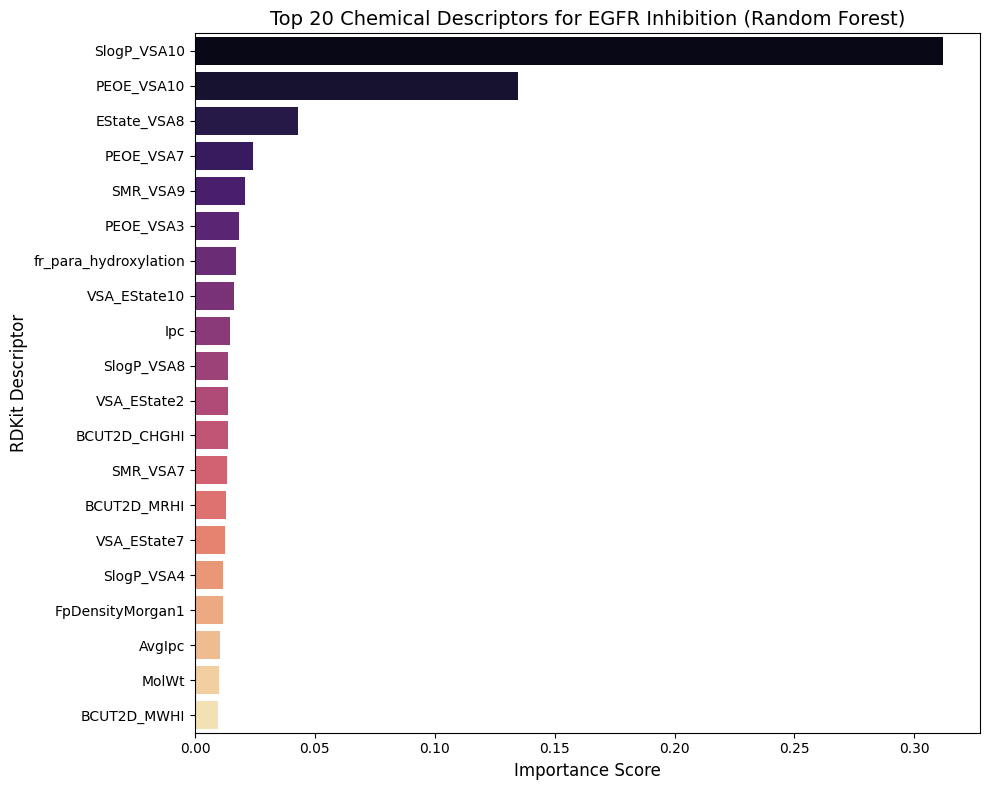

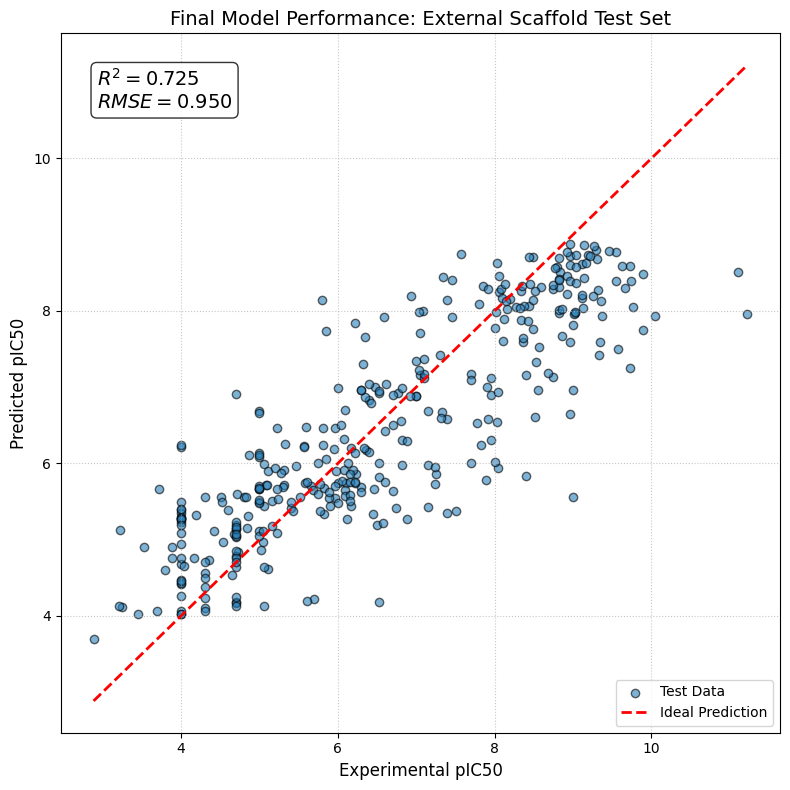

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load your scaffold split files
train_df = pd.read_csv('/content/EGFR_Scaffold_Train.csv')
test_df = pd.read_csv('/content/EGFR_Scaffold_Test.csv')

# 2. Prepare Features (X) and Target (y)
exclude = ['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'scaffold']
X_train = train_df.drop(columns=exclude)
y_train = train_df['pIC50']
X_test = test_df.drop(columns=exclude)
y_test = test_df['pIC50']

# 3. Re-train the winning Random Forest model
rf_final = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# 4. Extract Feature Importance
importances = rf_final.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Descriptor': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. Plot Top 20 Descriptors
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Descriptor', data=feature_importance_df.head(20), palette='magma')
plt.title('Top 20 Chemical Descriptors for EGFR Inhibition (Random Forest)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('RDKit Descriptor', fontsize=12)
plt.tight_layout()
plt.savefig('EGFR_Feature_Importance.png', dpi=300)
plt.show()

# 6. Generate Final Regression Plot (Test Set)
test_pred = rf_final.predict(X_test)
r2 = r2_score(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(8, 8))
plt.scatter(y_test, test_pred, alpha=0.6, color='#2980b9', edgecolors='k', label='Test Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction')

# Add metrics text box
stats_text = f'$R^2 = {r2:.3f}$\n$RMSE = {rmse:.3f}$'
plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=14,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Experimental pIC50', fontsize=12)
plt.ylabel('Predicted pIC50', fontsize=12)
plt.title('Final Model Performance: External Scaffold Test Set', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('EGFR_Final_Regression_Plot.png', dpi=300)
plt.show()

# 7. Save results for your report
feature_importance_df.to_csv('EGFR_Descriptor_Importance_Ranked.csv', index=False)
print

--- Calculating Training and Test Metrics ---
--- Running Y-Randomization (10 iterations per model) ---


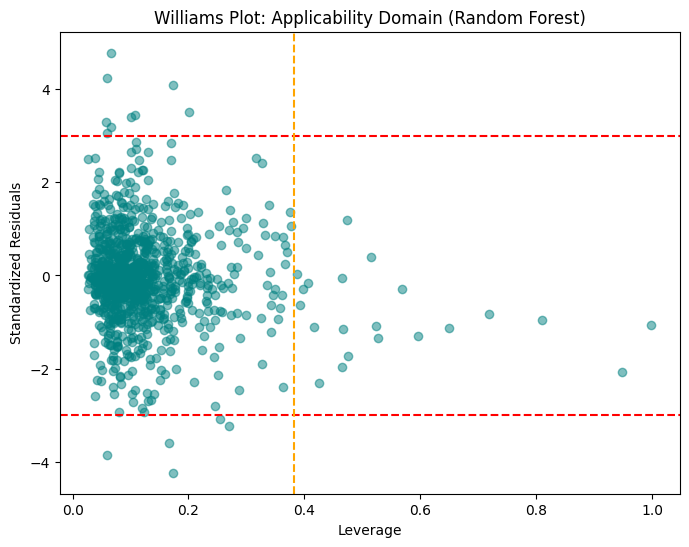

--- Extracting Feature Importance ---


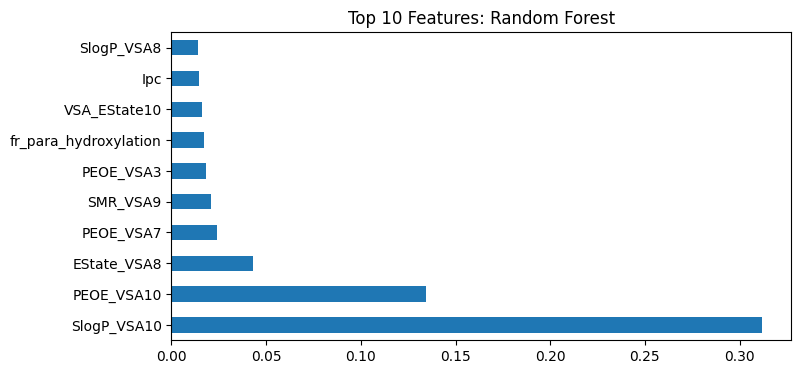

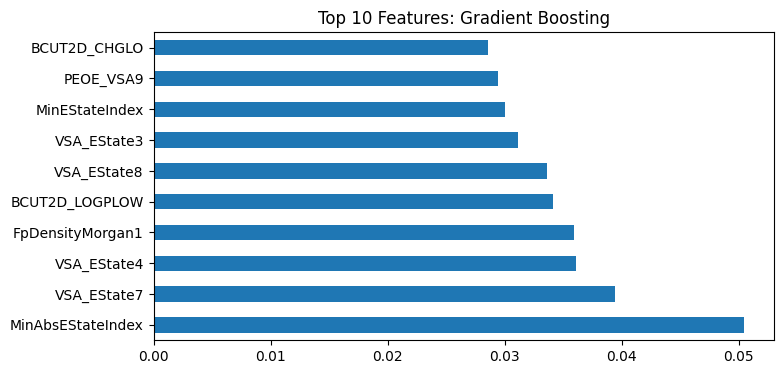

               Model  Train R2  Train RMSE   Test R2  Test RMSE  \
0      Random Forest  0.969759    0.286193  0.724520   0.950132   
1                SVR  0.824115    0.690202  0.650938   1.069523   
2  Gradient Boosting  0.984936    0.201989  0.652751   1.066741   

   Y-Rand R2 (Mean)  
0         -0.275864  
1         -0.456906  
2         -0.433325  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

# 1. Load Data
train_df = pd.read_csv('/content/EGFR_Scaffold_Train.csv')
test_df = pd.read_csv('/content/EGFR_Scaffold_Test.csv')

exclude = ['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'scaffold']
X_train = train_df.drop(columns=exclude)
y_train = train_df['pIC50']
X_test = test_df.drop(columns=exclude)
y_test = test_df['pIC50']

models = {
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42),
    "SVR": SVR(kernel='rbf'),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, random_state=42)
}

# --- TASK 1: Training vs Test Metrics ---
print("--- Calculating Training and Test Metrics ---")
comparison_data = []

for name, model in models.items():
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    comparison_data.append({
        "Model": name,
        "Train R2": r2_score(y_train, train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test R2": r2_score(y_test, test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    })

# --- TASK 2: Y-Randomization (Scrambling) ---
print("--- Running Y-Randomization (10 iterations per model) ---")
y_rand_results = {}

for name, model in models.items():
    rand_scores = []
    for i in range(10):
        y_shuffled = y_train.sample(frac=1, random_state=i)
        model.fit(X_train, y_shuffled)
        rand_scores.append(model.score(X_test, y_test))
    y_rand_results[name] = np.mean(rand_scores)

# --- TASK 3: Applicability Domain (Williams Plot for Scaffolds) ---
# Calculate Hat Matrix (Leverage)
X = X_train.values
X_inv = np.linalg.pinv(np.dot(X.T, X))
H = np.dot(np.dot(X, X_inv), X.T)
leverage = np.diagonal(H)
h_star = (3 * (X.shape[1] + 1)) / X.shape[0] # Warning threshold

# Standardized Residuals for RF (The best model)
rf = models["Random Forest"]
rf.fit(X_train, y_train)
residuals = y_train - rf.predict(X_train)
std_residuals = residuals / np.std(residuals)

plt.figure(figsize=(8, 6))
plt.scatter(leverage, std_residuals, alpha=0.5, color='teal')
plt.axhline(y=3, color='r', linestyle='--')
plt.axhline(y=-3, color='r', linestyle='--')
plt.axvline(x=h_star, color='orange', linestyle='--')
plt.title('Williams Plot: Applicability Domain (Random Forest)')
plt.xlabel('Leverage')
plt.ylabel('Standardized Residuals')
plt.savefig('Williams_Plot.png')
plt.show()

# --- TASK 4: Feature Importance Comparison ---
print("--- Extracting Feature Importance ---")
for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
        plt.figure(figsize=(8,4))
        feat_importances.nlargest(10).plot(kind='barh', title=f'Top 10 Features: {name}')
        plt.show()

# Final Summary Table
results_df = pd.DataFrame(comparison_data)
results_df['Y-Rand R2 (Mean)'] = results_df['Model'].map(y_rand_results)
print(results_df)

Calculating SVR Permutation Importance...


/tmp/ipykernel_1490/4037638236.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Descriptor', data=svr_feat_imp.head(10), palette='viridis')


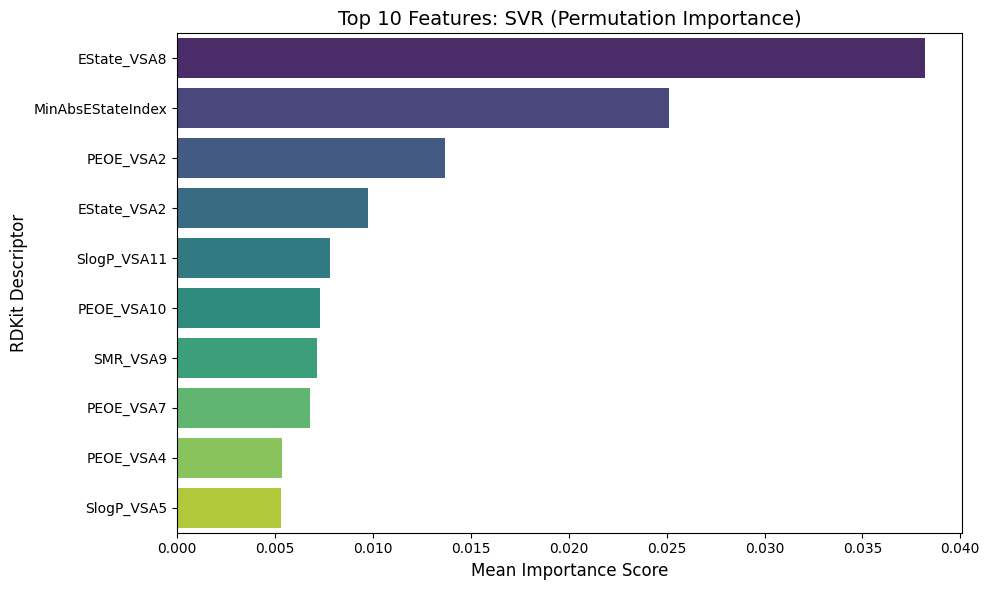

Top 5 SVR Descriptors:
           Descriptor  Importance
59        EState_VSA8    0.038200
1   MinAbsEStateIndex    0.025104
23          PEOE_VSA2    0.013703
53        EState_VSA2    0.009747
42        SlogP_VSA11    0.007793


In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate Permutation Importance for SVR
# This will take a moment as it re-evaluates the model multiple times
print("Calculating SVR Permutation Importance...")
svr_result = permutation_importance(models["SVR"], X_test, y_test,
                                    n_repeats=10, random_state=42, n_jobs=-1)

# 2. Organize into a DataFrame
svr_feat_imp = pd.DataFrame({
    'Descriptor': X_test.columns,
    'Importance': svr_result.importances_mean
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top 10 SVR Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Descriptor', data=svr_feat_imp.head(10), palette='viridis')
plt.title('Top 10 Features: SVR (Permutation Importance)', fontsize=14)
plt.xlabel('Mean Importance Score', fontsize=12)
plt.ylabel('RDKit Descriptor', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Print the comparison
print("Top 5 SVR Descriptors:")
print(svr_feat_imp.head(5))